In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_distributions(df):
    # Generically define how many plots along and across
    ncols = 3
    nrows = int(np.ceil(len(df) / (1.0*ncols)))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 6))

    # Lazy counter so we can remove unwated axes
    counter = 0
    for i in range(nrows):
        for j in range(ncols):

            ax = axes[i][j]

            # Plot when we have data
            if counter < len(df):

                ax.hist(df[counter], bins=20, color='purple', alpha=1, density=True)
                if i == 1:
                    ax.set_xlabel("Error")
                if i == 0:
                    if j == 0:
                        ax.set_title('Train')
                    elif j == 1:
                        ax.set_title("Test")
                    else:
                        ax.set_title("Test generalization")
                if j == 0:
                    if i == 0:
                        ax.set_ylabel('Normalized frecuency (A)')
                    else:
                        ax.set_ylabel('Normalized frecuency (B)')
                ax.set_ylim([0, 0.6])
                ax.set_xlim([-7, 7])
                #leg = ax.legend(loc='upper left')
                #leg.draw_frame(True)

            # Remove axis when we no longer have data
            else:
                ax.set_axis_off()

            counter += 1

    # fig.supxlabel('Error')
    #fig.supylabel('Frecuency')
    plt.show()


In [ ]:
def plot_dispersion(df):
    # Generically define how many plots along and across
    ncols = 3
    nrows = int(np.ceil(len(df) / (1.0*ncols)))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 6))

    # Lazy counter so we can remove unwated axes
    counter = 0
    for i in range(nrows):
        for j in range(ncols):

            ax = axes[i][j]
            ax.grid()

            # Plot when we have data
            if counter < len(df):

                ax.scatter(df[counter]['expected'], df[counter]['error'], color='purple', alpha=1)
                if i == 1:
                    ax.set_xlabel("Real Vol(K)")
                if i == 0:
                    if j == 0:
                        ax.set_title('Train')
                    elif j == 1:
                        ax.set_title("Test")
                    else:
                        ax.set_title("Test generalization")
                if j == 0:
                    if i == 0:
                        ax.set_ylabel('Error (A)')
                    else:
                        ax.set_ylabel('Error (B)')
                ax.set_ylim([-15, 15])
                ax.set_xlim([0, 23])
                #leg = ax.legend(loc='upper left')
                #leg.draw_frame(True)

            # Remove axis when we no longer have data
            else:
                ax.set_axis_off()
            
            counter += 1

    # fig.supxlabel('Error')
    #fig.supylabel('Frecuency')
    plt.show()

In [10]:
from scipy.stats import gaussian_kde
from matplotlib import cm


def plot_dispersion_wDensity(df):
    # Generically define how many plots along and across
    ncols = 3
    nrows = int(np.ceil(len(df) / (1.0*ncols)))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 6))

    # Lazy counter so we can remove unwated axes
    counter = 0
    for i in range(nrows):
        for j in range(ncols):

            ax = axes[i][j]
            ax.grid(alpha = 0.5)

            # Plot when we have data
            if counter < len(df):
                x = df[counter]['expected'].to_numpy()
                y = df[counter]['error'].to_numpy()

                xy = np.vstack([x,y])
                z = gaussian_kde(xy)(xy)
                # Sort the points by density, so that the densest points are plotted last
                idx = z.argsort()
                x, y, z = x[idx], y[idx], z[idx]

                ax.scatter(x, y, c=z, s=50)
                if i == 1:
                    ax.set_xlabel("Real Vol(K)")
                if i == 0:
                    if j == 0:
                        ax.set_title('Train')
                    elif j == 1:
                        ax.set_title("Test")
                    else:
                        ax.set_title("Test generalization")
                if j == 0:
                    if i == 0:
                        ax.set_ylabel('Error (A)')
                    else:
                        ax.set_ylabel('Error (B)')
                ax.set_ylim([-15, 15])
                ax.set_xlim([0, 23])
                #leg = ax.legend(loc='upper left')
                #leg.draw_frame(True)

            # Remove axis when we no longer have data
            else:
                ax.set_axis_off()
            
            counter += 1

    # fig.supxlabel('Error')
    #fig.supylabel('Frecuency')
    cb = cm.ScalarMappable(cmap='viridis')
    #fig.colorbar(cb, ax = axbig)

    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.82, 0.15, 0.02, 0.7])
    #cbar_ax.set_ylabel('# of contacts', rotation=270)
    fig.colorbar(cb, cax=cbar_ax)
    plt.show()

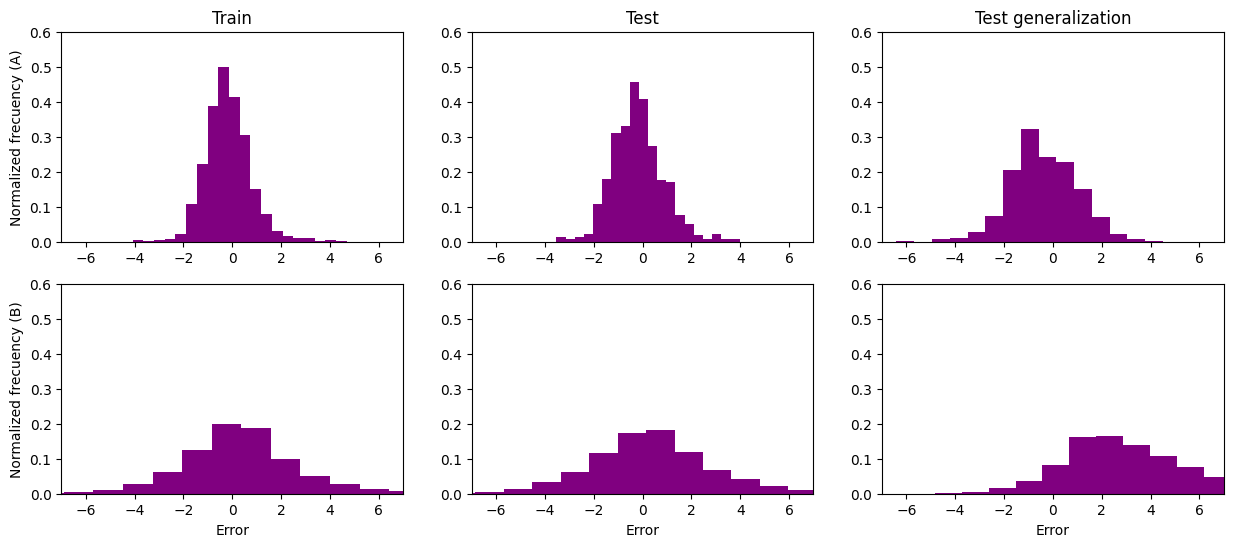

In [5]:
dfA = pd.read_csv('../outputs/results-experimentA.csv')
dfB = pd.read_csv('../outputs/results-experimentB.csv')
plot_distributions([dfA.loc[dfA['set'] == 'train']['error'].to_numpy(),
                    dfA.loc[dfA['set'] == 'test']['error'].to_numpy(),
                    dfA.loc[dfA['set'] == 'test_gen']['error'].to_numpy(),
                    dfB.loc[dfB['set'] == 'train']['error'].to_numpy(),
                    dfB.loc[dfB['set'] == 'test']['error'].to_numpy(),
                    dfB.loc[dfB['set'] == 'test_gen']['error'].to_numpy()])

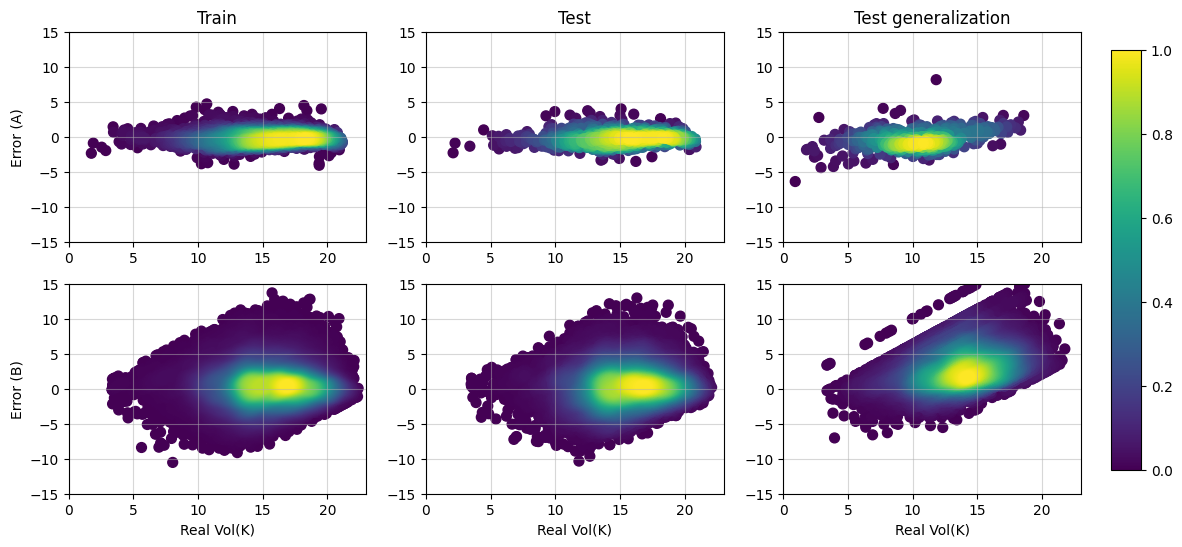

In [11]:
plot_dispersion_wDensity([dfA.loc[dfA['set'] == 'train'][['expected', 'error']],
                          dfA.loc[dfA['set'] == 'test'][['expected', 'error']],
                          dfA.loc[dfA['set'] == 'test_gen'][['expected', 'error']],
                          dfB.loc[dfB['set'] == 'train'][['expected', 'error']],
                          dfB.loc[dfB['set'] == 'test'][['expected', 'error']],
                          dfB.loc[dfB['set'] == 'test_gen'][['expected', 'error']]])

In [35]:
dfA.describe()

,real,expected,error
count,3365.000000,3365.000000,3365.000000
mean,14.533384,14.333066,-0.200317
std,3.756787,3.716823,1.035509
min,0.000287,0.926625,-6.401100
25%,12.179299,11.854302,-0.843605
50%,14.822445,14.611142,-0.275067
75%,17.277327,17.148556,0.383478
max,23.438688,21.151205,8.148970


In [8]:
dfB.describe()

,real,expected,error
count,104375.000000,104375.000000,104375.000000
mean,14.531867,15.234693,0.702826
std,3.755933,2.730705,2.593680
min,0.000287,3.367245,-10.527403
25%,12.172259,13.530730,-0.868647
50%,14.816120,15.276052,0.501051
75%,17.277327,17.193363,2.034711
max,23.438688,22.367739,14.981827
